# TCN on Baseline Input (Reproducible)
This notebook trains a TCN on the exact same `.mat`-derived `(N, 30, 9)` representation used by the baseline models.

## Imports & Seed

In [1]:
import os
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cpu


## Config

In [2]:
LABEL_NAMES = [
    'groom',
    'inner_tube_success', 'inner_tube_fail',
    'outer_edge_success', 'outer_edge_fail',
    'under_tube_success', 'under_tube_fail',
]
N_CLASSES = len(LABEL_NAMES)

WINDOW_PRE = 0.20
WINDOW_POST = 0.40
BIN_SIZE = 0.020
N_BINS = int(round((WINDOW_PRE + WINDOW_POST) / BIN_SIZE))  # 30

LOCAL_MATS = ['1D_1.mat', '1D_2.mat']
KAGGLE_MATS = [
    '/kaggle/input/datasets/mahama5if/pc-spikes/1D_1.mat',
    '/kaggle/input/datasets/mahama5if/pc-spikes/1D_2.mat',
]
MAT_PATHS = LOCAL_MATS if all(os.path.exists(p) for p in LOCAL_MATS) else KAGGLE_MATS

CONFIG = {
    'val_size': 0.15,
    'test_size': 0.15,
    'batch_size': 64,
    'epochs': 80,
    'lr': 8e-4,
    'weight_decay': 1e-4,
    'grad_clip': 1.0,
    'use_class_weights': True,
    'use_weighted_sampler': True,
}

print('N_BINS:', N_BINS)
print('MAT_PATHS:', MAT_PATHS)


N_BINS: 30
MAT_PATHS: ['1D_1.mat', '1D_2.mat']


## Baseline-Equivalent Data Loader (.mat -> N x 30 x 9)

In [3]:
def _spike_psth(spike_times, lick_onsets):
    bins = np.linspace(-WINDOW_PRE, WINDOW_POST, N_BINS + 1)
    psth = np.zeros((len(lick_onsets), N_BINS), dtype=np.float32)
    for i, onset in enumerate(lick_onsets):
        t_rel = spike_times - onset
        mask = (t_rel >= -WINDOW_PRE) & (t_rel <= WINDOW_POST)
        psth[i], _ = np.histogram(t_rel[mask], bins=bins)
    return psth


def _find_spike_pair(refs, lick_key):
    onsets = refs[f'{lick_key}/time_onset'][()].flatten()
    lick_start, lick_end = onsets[0], onsets[-1]

    all_spike_keys = [
        k for k in refs
        if hasattr(refs[k], 'keys') and 'SS_time' in refs[k] and 'CS_time' in refs[k]
    ]

    scored = []
    for k in all_spike_keys:
        ss = refs[f'{k}/SS_time'][()].flatten()
        overlap_direct = int(((ss >= lick_start) & (ss <= lick_end)).sum())
        scored.append((k, overlap_direct, ss[0]))

    scored.sort(key=lambda t: -t[1])

    if scored[0][1] == 0:
        ref_start = scored[0][2]
        rescored = []
        for k, _, ss0 in scored:
            ss = refs[f'{k}/SS_time'][()].flatten()
            offset = ref_start - ss0
            ss_c = ss + offset
            ov = int(((ss_c >= lick_start) & (ss_c <= lick_end)).sum())
            rescored.append((k, offset, ov))
        rescored.sort(key=lambda t: -t[2])
        key_n1, off_n1 = rescored[0][0], rescored[0][1]
        key_n2 = rescored[1][0] if len(rescored) > 1 else key_n1
        off_n2 = rescored[1][1] if len(rescored) > 1 else off_n1
        return key_n1, off_n1, key_n2, off_n2

    key_n1, off_n1 = scored[0][0], 0.0
    abs_start = refs[f'{key_n1}/SS_time'][()].flatten()[0]

    remaining = scored[1:]
    if remaining:
        rel_pairs = []
        for k, direct_ov, ss0 in remaining:
            if direct_ov > 0:
                rel_pairs.append((k, 0.0, direct_ov))
            else:
                ss = refs[f'{k}/SS_time'][()].flatten()
                offset = abs_start - ss0
                ss_c = ss + offset
                ov = int(((ss_c >= lick_start) & (ss_c <= lick_end)).sum())
                rel_pairs.append((k, offset, ov))
        rel_pairs.sort(key=lambda t: -t[2])
        key_n2, off_n2 = rel_pairs[0][0], rel_pairs[0][1]
    else:
        key_n2, off_n2 = key_n1, 0.0

    return key_n1, off_n1, key_n2, off_n2


def _load_session(f, lick_key):
    refs = f['#refs#']
    lick_grp = refs[lick_key]

    y = lick_grp['tag_lick'][()].flatten().astype(int) - 1
    onsets = lick_grp['time_onset'][()].flatten()

    k_n1, off_n1, k_n2, off_n2 = _find_spike_pair(refs, lick_key)

    ss_n1 = refs[f'{k_n1}/SS_time'][()].flatten() + off_n1
    cs_n1 = refs[f'{k_n1}/CS_time'][()].flatten() + off_n1
    ss_n2 = refs[f'{k_n2}/SS_time'][()].flatten() + off_n2
    cs_n2 = refs[f'{k_n2}/CS_time'][()].flatten() + off_n2

    X_seq = np.stack([
        _spike_psth(ss_n1, onsets),
        _spike_psth(ss_n2, onsets),
        _spike_psth(cs_n1, onsets),
        _spike_psth(cs_n2, onsets),
    ], axis=-1)

    kin_keys = ['duration_lick', 'tongue_vm_max', 'tongue_vm_min', 'tongue_dm_max', 'tongue_ang_max']
    X_kin = np.column_stack([lick_grp[k][()].flatten() for k in kin_keys]).astype(np.float32)

    return X_seq, X_kin, y


def load_mat_file(path):
    X_seq_all, X_kin_all, y_all = [], [], []
    with h5py.File(path, 'r') as f:
        refs = f['#refs#']
        lick_keys = sorted(
            [k for k in refs if hasattr(refs[k], 'keys') and 'tag_lick' in refs[k]],
            key=lambda k: float(refs[f'{k}/time_onset'][()].flatten()[0]),
        )
        print(f'  {len(lick_keys)} session(s) in {path}')
        for lk in lick_keys:
            xs, xk, yy = _load_session(f, lk)
            X_seq_all.append(xs)
            X_kin_all.append(xk)
            y_all.append(yy)

    return np.concatenate(X_seq_all), np.concatenate(X_kin_all), np.concatenate(y_all)


def build_arrays(mat_paths, val_size=0.15, test_size=0.15, seed=42):
    seqs, kins, ys = [], [], []
    print('Loading data...')
    for p in mat_paths:
        xs, xk, yy = load_mat_file(p)
        seqs.append(xs)
        kins.append(xk)
        ys.append(yy)

    X_seq = np.concatenate(seqs)
    X_kin = np.concatenate(kins)
    y = np.concatenate(ys)

    idx = np.arange(len(y))
    idx_tv, idx_test = train_test_split(idx, test_size=test_size, stratify=y, random_state=seed)
    idx_train, idx_val = train_test_split(
        idx_tv,
        test_size=val_size / (1 - test_size),
        stratify=y[idx_tv],
        random_state=seed,
    )

    N, T, C = X_seq.shape
    sc_seq = StandardScaler().fit(X_seq[idx_train].reshape(-1, C))
    sc_kin = StandardScaler().fit(X_kin[idx_train])

    X_seq_n = sc_seq.transform(X_seq.reshape(-1, C)).reshape(N, T, C)
    X_kin_n = sc_kin.transform(X_kin)
    X_kin_seq = np.repeat(X_kin_n[:, np.newaxis, :], T, axis=1)
    X = np.concatenate([X_seq_n, X_kin_seq], axis=-1).astype(np.float32)

    if np.isnan(X).any() or np.isinf(X).any():
        bad = np.where(~np.isfinite(X))
        raise ValueError(f'Non-finite values in X at indices sample: {list(zip(*[b[:5] for b in bad]))}')

    class_counts = np.bincount(y, minlength=N_CLASSES).astype(float)
    class_weights = 1.0 / np.where(class_counts > 0, class_counts, 1.0)
    class_weights = class_weights / class_weights.sum()

    print(f'Total licks: {len(y)}')
    for i, c in enumerate(class_counts.astype(int)):
        print(f'  [{i}] {LABEL_NAMES[i]}: {c}')
    print(f'Split: train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}')

    return X, y, idx_train, idx_val, idx_test, torch.tensor(class_weights, dtype=torch.float32)


## Build Datasets & Loaders

In [4]:
X, y, idx_train, idx_val, idx_test, class_weights = build_arrays(
    MAT_PATHS,
    val_size=CONFIG['val_size'],
    test_size=CONFIG['test_size'],
    seed=SEED,
)

class LickDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)   # (N, T, C)
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        # Conv1d input: (C, T)
        return self.X[i].transpose(0, 1), self.y[i]

train_ds = LickDataset(X[idx_train], y[idx_train])
val_ds = LickDataset(X[idx_val], y[idx_val])
test_ds = LickDataset(X[idx_test], y[idx_test])

if CONFIG['use_weighted_sampler']:
    tr_labels = y[idx_train]
    counts = np.bincount(tr_labels, minlength=N_CLASSES)
    sample_w = torch.from_numpy((1.0 / counts[tr_labels]).astype(np.float32))
    sampler = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)

val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)


Loading data...
  3 session(s) in 1D_1.mat
  5 session(s) in 1D_2.mat
Total licks: 14002
  [0] groom: 2522
  [1] inner_tube_success: 652
  [2] inner_tube_fail: 353
  [3] outer_edge_success: 52
  [4] outer_edge_fail: 2396
  [5] under_tube_success: 1783
  [6] under_tube_fail: 6244
Split: train=9800, val=2101, test=2101


## TCN Model

In [5]:
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, d=1, p_drop=0.2):
        super().__init__()
        pad = (k - 1) * d
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=k, dilation=d, padding=pad)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=k, dilation=d, padding=pad)
        self.norm1 = nn.BatchNorm1d(out_ch)
        self.norm2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(p_drop)
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.k = k
        self.d = d

    def _chomp(self, x):
        cut = (self.k - 1) * self.d
        return x[:, :, :-cut] if cut > 0 else x

    def forward(self, x):
        y = self._chomp(self.conv1(x))
        y = self.drop(F.gelu(self.norm1(y)))
        y = self._chomp(self.conv2(y))
        y = self.drop(F.gelu(self.norm2(y)))
        return y + self.down(x)


class TCNClassifier(nn.Module):
    def __init__(self, in_ch=9, channels=(64, 64, 96, 96), k=3, p_drop=0.2, n_classes=7):
        super().__init__()
        layers = []
        c = in_ch
        for i, out_c in enumerate(channels):
            layers.append(TemporalBlock(c, out_c, k=k, d=2**i, p_drop=p_drop))
            c = out_c
        self.tcn = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Linear(c, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        h = self.tcn(x)
        h = h.mean(dim=-1)
        return self.head(h)


model = TCNClassifier(in_ch=9, n_classes=N_CLASSES).to(device)
print('Trainable params:', sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable params: 162087


## Train / Eval

In [6]:
criterion = nn.CrossEntropyLoss(weight=(class_weights.to(device) if CONFIG['use_class_weights'] else None))
optimizer = AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-5)


def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss = 0.0
    all_preds, all_true = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG['grad_clip'])
                optimizer.step()

        total_loss += loss.item() * len(yb)
        all_preds.extend(logits.argmax(1).detach().cpu().numpy())
        all_true.extend(yb.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    bac = balanced_accuracy_score(all_true, all_preds)
    acc = (np.array(all_preds) == np.array(all_true)).mean()
    return avg_loss, acc, bac, np.array(all_preds), np.array(all_true)


history = {'tr_loss': [], 'va_loss': [], 'tr_bac': [], 'va_bac': []}
best_bac = -1.0
best_state = None

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc, tr_bac, _, _ = run_epoch(model, train_loader, train=True)
    va_loss, va_acc, va_bac, _, _ = run_epoch(model, val_loader, train=False)
    scheduler.step()

    history['tr_loss'].append(tr_loss)
    history['va_loss'].append(va_loss)
    history['tr_bac'].append(tr_bac)
    history['va_bac'].append(va_bac)

    if va_bac > best_bac:
        best_bac = va_bac
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(f'Epoch {epoch:03d} | tr_loss={tr_loss:.4f} va_loss={va_loss:.4f} | tr_bac={tr_bac:.4f} va_bac={va_bac:.4f}')

print(f'Best val balanced accuracy: {best_bac:.4f}')
model.load_state_dict(best_state)


Epoch 001 | tr_loss=0.3377 va_loss=1.2472 | tr_bac=0.5308 va_bac=0.6369
Epoch 005 | tr_loss=0.1377 va_loss=1.0452 | tr_bac=0.7196 va_bac=0.6805
Epoch 010 | tr_loss=0.1150 va_loss=1.1004 | tr_bac=0.7566 va_bac=0.6625
Epoch 015 | tr_loss=0.1015 va_loss=1.3715 | tr_bac=0.7726 va_bac=0.6801
Epoch 020 | tr_loss=0.0937 va_loss=1.3688 | tr_bac=0.7770 va_bac=0.6443
Epoch 025 | tr_loss=0.0847 va_loss=1.4402 | tr_bac=0.7833 va_bac=0.6551
Epoch 030 | tr_loss=0.0728 va_loss=1.5906 | tr_bac=0.7990 va_bac=0.6379
Epoch 035 | tr_loss=0.0617 va_loss=1.6059 | tr_bac=0.8084 va_bac=0.6512
Epoch 040 | tr_loss=0.0644 va_loss=1.7479 | tr_bac=0.8097 va_bac=0.6499
Epoch 045 | tr_loss=0.0567 va_loss=1.7047 | tr_bac=0.8235 va_bac=0.6575
Epoch 050 | tr_loss=0.0480 va_loss=1.7279 | tr_bac=0.8230 va_bac=0.6608
Epoch 055 | tr_loss=0.0476 va_loss=1.8408 | tr_bac=0.8323 va_bac=0.6629
Epoch 060 | tr_loss=0.0442 va_loss=1.8900 | tr_bac=0.8401 va_bac=0.6685
Epoch 065 | tr_loss=0.0422 va_loss=1.9401 | tr_bac=0.8379 va_bac

<All keys matched successfully>

## Validation Metrics

In [7]:
va_loss, va_acc, va_bac, va_pred, va_true = run_epoch(model, val_loader, train=False)
print(f'Val loss: {va_loss:.4f}')
print(f'Val acc:  {va_acc:.4f}')
print(f'Val bac:  {va_bac:.4f}')
print('Classification report (val):')
print(classification_report(va_true, va_pred, target_names=LABEL_NAMES, digits=4, zero_division=0))


Val loss: 1.0738
Val acc:  0.4607
Val bac:  0.7086
Classification report (val):
                    precision    recall  f1-score   support

             groom     0.8016    0.8016    0.8016       378
inner_tube_success     0.3333    0.7959    0.4699        98
   inner_tube_fail     0.0865    0.8679    0.1573        53
outer_edge_success     0.0897    0.8750    0.1628         8
   outer_edge_fail     0.7716    0.7694    0.7705       360
under_tube_success     0.4507    0.8052    0.5780       267
   under_tube_fail     0.9767    0.0448    0.0857       937

          accuracy                         0.4607      2101
         macro avg     0.5015    0.7086    0.4322      2101
      weighted avg     0.7874    0.4607    0.4144      2101



## Test Metrics

In [8]:
te_loss, te_acc, te_bac, te_pred, te_true = run_epoch(model, test_loader, train=False)
print(f'Test loss: {te_loss:.4f}')
print(f'Test acc:  {te_acc:.4f}')
print(f'Test bac:  {te_bac:.4f}')


Test loss: 1.0045
Test acc:  0.4607
Test bac:  0.7177


## Curves & Confusion Matrix

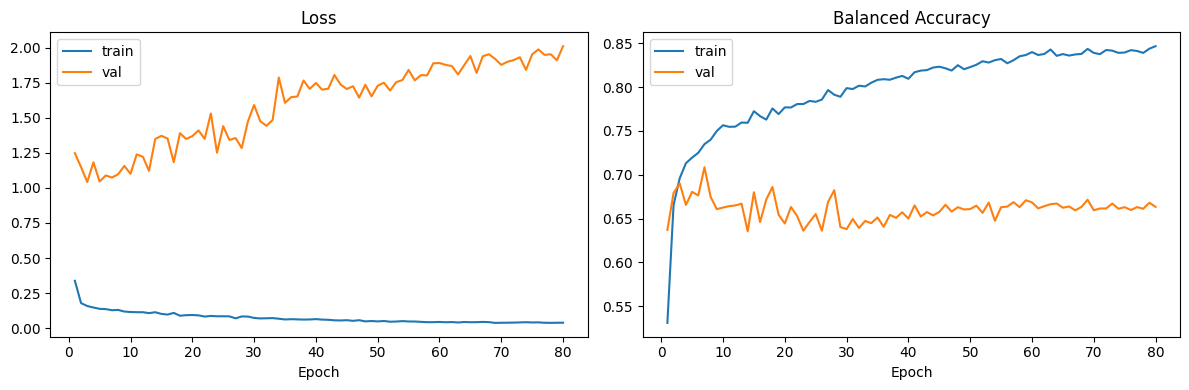

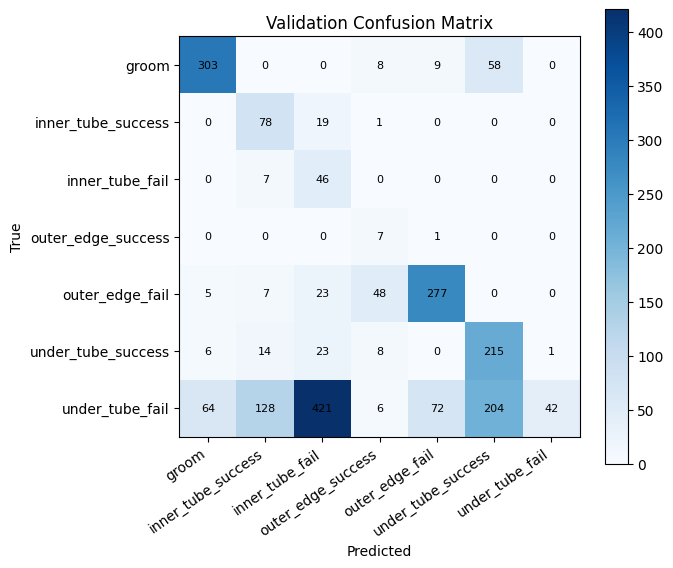

In [9]:
epochs = np.arange(1, CONFIG['epochs'] + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, history['tr_loss'], label='train')
ax[0].plot(epochs, history['va_loss'], label='val')
ax[0].set_title('Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(epochs, history['tr_bac'], label='train')
ax[1].plot(epochs, history['va_bac'], label='val')
ax[1].set_title('Balanced Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(va_true, va_pred, labels=np.arange(N_CLASSES))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Validation Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks(np.arange(N_CLASSES))
ax.set_yticks(np.arange(N_CLASSES))
ax.set_xticklabels(LABEL_NAMES, rotation=35, ha='right')
ax.set_yticklabels(LABEL_NAMES)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Save Checkpoint

In [10]:
ckpt = {
    'model_state_dict': model.state_dict(),
    'best_val_bac': best_bac,
    'config': CONFIG,
    'label_names': LABEL_NAMES,
    'seed': SEED,
    'mat_paths': MAT_PATHS,
}

torch.save(ckpt, 'tcn_baseline_input_checkpoint.pt')
print('Saved: tcn_baseline_input_checkpoint.pt')


Saved: tcn_baseline_input_checkpoint.pt
